In [1]:
import pandas as pd
import numpy as np
import math
import warnings

def addColumns(data):
    #Add Responders vs Non Responder:
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])

    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'

    return data

seed = 42
syn_datas = ["original_data",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
dataset_dict = {}
for syn_data in syn_datas:
    print(f"-----{syn_data}-----")
    df = pd.read_csv(f"Data/{syn_data}.csv",index_col = 0)
    processed_df = addColumns(df)
    dataset_dict[syn_data] = processed_df

-----original_data-----
-----avatarsk10_42-----
-----ctgan_42-----
-----gaussiancopula_42-----
-----synthpop_42-----
-----tvae_42-----


In [3]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0):

    ph_column, ph_values = next(iter(phenotypes.items()))
    if len(ph_values) != 2:
        raise ValueError(f"Phenotype values list must contain exactly two values, got: {ph_values}")

    phenotype_A, phenotype_B = ph_values

    phenotypeA_samples = metadata[metadata[ph_column] == phenotype_A][id_col].values.tolist()
    phenotypeB_samples = metadata[metadata[ph_column] == phenotype_B][id_col].values.tolist()

    if len(phenotypeA_samples) == 0 or len(phenotypeB_samples) == 0:
        raise ValueError("One of the phenotype groups has no samples.")

    phenotypeA_DF = gene_expressions.loc[phenotypeA_samples, :]
    phenotypeB_DF = gene_expressions.loc[phenotypeB_samples, :]

    genelist = gene_expressions.columns.tolist()

    def process_gene(gene):
        phenotypeA_exp = phenotypeA_DF[gene].values
        phenotypeB_exp = phenotypeB_DF[gene].values

        # Edge case flags
        status = []

        # Handle arrays full of NaN or empty
        if np.all(np.isnan(phenotypeA_exp)) or len(phenotypeA_exp) == 0:
            status.append(f"A_all_nan_or_empty")
        if np.all(np.isnan(phenotypeB_exp)) or len(phenotypeB_exp) == 0:
            status.append(f"B_all_nan_or_empty")

        # Remove NaNs (rank-sum test can't handle)
        cleaned_A_exp = phenotypeA_exp[~np.isnan(phenotypeA_exp)]
        cleaned_B_exp = phenotypeB_exp[~np.isnan(phenotypeB_exp)]

        if len(cleaned_A_exp) == 0 or len(cleaned_B_exp) == 0:
            pvalue = np.nan
            status.append("No_data")
        else:
            # Check if both are constant or identical
            if np.all(cleaned_A_exp == cleaned_A_exp[0]) and np.all(cleaned_B_exp == cleaned_B_exp[0]) and cleaned_A_exp[0] == cleaned_B_exp[0]:
                pvalue = 1.0
                status.append("Identical")
            else:
                try:
                    _, pvalue = ranksums(cleaned_A_exp, cleaned_B_exp, alternative='two-sided')
                    if np.isnan(pvalue):
                        status.append("p_nan")
                except Exception as e:
                    pvalue = np.nan
                    status.append(f"ranksums_error:{str(e)}")

        mean_A = np.nanmean(cleaned_A_exp) if len(cleaned_A_exp) else np.nan
        mean_B = np.nanmean(cleaned_B_exp) if len(cleaned_B_exp) else np.nan

        # Log2FC with safe handling (including zeros, NaN, infinite)
        if np.isnan(mean_A) or np.isnan(mean_B):
            log2fc = np.nan
            status.append("FC_nan")
        elif mean_A == mean_B == 0:
            log2fc = 0.0
            status.append("FC_both_zero")
        elif mean_B == 0:
            log2fc = np.inf if mean_A > 0 else np.nan
            status.append("FC_div_zero")
        elif mean_A == 0:
            log2fc = -np.inf if mean_B > 0 else np.nan
            status.append("FC_div_zero")
        else:
            log2fc = np.log2(mean_A / mean_B)

        if not status:
            status = ["ok"]
        return pvalue, log2fc, ";".join(status)

    # Parallel processing
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(process_gene)(gene) for gene in tqdm(genelist, desc="DE analysis")
    )
    pvalues, log2FCs, statusflags = zip(*results)

    
    results_df = pd.DataFrame(
        {
            "Gene": genelist,
            "P_value": pvalues,
            "Log2FC": log2FCs,
            "Status": statusflags,
        }
    )
    
    # Multiple testing correction (protect against all-NaN p-values)
    pvalues = np.asarray(results_df["P_value"].values)
    valid_p_mask = ~pd.isnull(pvalues)
    valid_pvalues = np.array(pvalues)[valid_p_mask]
    qvalues = np.full_like(pvalues, np.nan, dtype=np.double)
    if valid_pvalues.size > 0:
        _, qvals_valid, _, _ = multipletests(valid_pvalues, method='fdr_bh')
        qvalues = np.array(qvalues)
        qvalues[valid_p_mask] = qvals_valid
    
    results_df['Q_value'] = qvalues
    # Rank_Score is only computed for valid Log2FC and Q_value
    results_df["Rank_Score"] = np.where(
        pd.isnull(results_df["Log2FC"]) | pd.isnull(results_df["Q_value"]),
        np.nan,
        np.sign(results_df["Log2FC"]) * (-np.log10(results_df["Q_value"]))
    )
    return results_df

In [4]:
degs_results = {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    genelist = data.columns.tolist()[54:-1]
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PD_Responders": data["PD_Responders"].values.tolist()}
    )
    gene_expressions = data[genelist]
    # id_col = "Patient"
    # phenotypes = {"PD_Responders": ["Responder","Progressor"]}
    # degs_df = degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    # degs_results[name] = degs_df

----DEGs Analysis original_data ----
----DEGs Analysis avatarsk10_42 ----
----DEGs Analysis ctgan_42 ----
----DEGs Analysis gaussiancopula_42 ----
----DEGs Analysis synthpop_42 ----
----DEGs Analysis tvae_42 ----


In [103]:
import gseapy as gp
hallmarks_gmt = "../PublicationData/h.all.v2025.1.Hs.symbols.gmt"
GSEA_overall = {}
for name, degs in degs_results.items():
    print(f"----GSEA {name}----")
    ranked_results_df = degs.sort_values(by="Rank_Score", ascending = False)
    rnk = ranked_results_df[["Gene","Rank_Score"]].set_index("Gene")
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=hallmarks_gmt,
                         threads=32,
                         permutation_num=10000, # reduce number to speed up testing
                         outdir=None, # don't write to disk
                         seed=seed,
                         verbose=True)
    prerank_overall = pre_res.res2d
    prerank_overall.to_csv(f"GSEA/GSEA_{name}_{seed}.csv",index = False)
    GSEA_overall[name] = prerank_overall

2025-11-30 23:40:20,014 [WARNING] Duplicated values found in preranked stats: 96.21% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-30 23:40:20,016 [INFO] Parsing data files for GSEA.............................
2025-11-30 23:40:20,060 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-30 23:40:20,061 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-30 23:40:20,062 [INFO] Start to run GSEA...Might take a while..................


----GSEA original_data----


2025-11-30 23:40:32,229 [INFO] Congratulations. GSEApy runs successfully................

2025-11-30 23:40:32,254 [WARNING] Duplicated values found in preranked stats: 95.94% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-30 23:40:32,255 [INFO] Parsing data files for GSEA.............................
2025-11-30 23:40:32,283 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-30 23:40:32,285 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-30 23:40:32,285 [INFO] Start to run GSEA...Might take a while..................


----GSEA avatarsk10_42----


2025-11-30 23:40:42,956 [INFO] Congratulations. GSEApy runs successfully................

2025-11-30 23:40:43,029 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-11-30 23:40:43,042 [WARNING] Duplicated values found in preranked stats: 97.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-30 23:40:43,044 [INFO] Parsing data files for GSEA.............................
2025-11-30 23:40:43,071 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-30 23:40:43,073 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-30 23:40:43,074 [INFO] Start to run GSEA...Might take a while..................


...

2025-11-30 23:41:04,236 [INFO] Congratulations. GSEApy runs successfully................

2025-11-30 23:41:04,643 [WARNING] Duplicated values found in preranked stats: 99.93% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-30 23:41:04,645 [INFO] Parsing data files for GSEA.............................
2025-11-30 23:41:04,674 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-30 23:41:04,675 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-30 23:41:04,676 [INFO] Start to run GSEA...Might take a while..................


----GSEA synthpop_42----


2025-11-30 23:41:15,279 [INFO] Congratulations. GSEApy runs successfully................

2025-11-30 23:41:15,546 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-11-30 23:41:15,555 [WARNING] Duplicated values found in preranked stats: 95.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-30 23:41:15,556 [INFO] Parsing data files for GSEA.............................
2025-11-30 23:41:15,584 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-30 23:41:15,586 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-30 23:41:15,587 [INFO] Start to run GSEA...Might take a while..................


----GSEA tvae_42----


2025-11-30 23:41:26,282 [INFO] Congratulations. GSEApy runs successfully................



In [106]:
from collections import Iterable
from typing import Dict, Optional, Tuple, Any, List

def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "P_value",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

In [189]:
orig_paths = extract_significant_pathways(GSEA_overall["original_data"], term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
synth_paths_dict = {k: extract_significant_pathways(v, term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
                     for k, v in GSEA_overall.items() if k != "original_data"}
jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
# jaccard_df.to_csv(f"GSEA/JaccardIndex_{seed}.csv", index = False)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk10_42,25,28,16,37,0.432432
1,ctgan_42,25,0,0,25,0.000000
2,gaussiancopula_42,25,3,2,26,0.076923
3,synthpop_42,25,21,14,32,0.437500
4,tvae_42,25,12,8,29,0.275862


In [144]:
from scipy.stats import spearmanr
GSEA_list = []
for name, df in GSEA_overall.items():
    df["Dataset"] = name
    GSEA_list.append(df)
GSEA_df = pd.concat(GSEA_list, axis = 0)
pivot_df = GSEA_df.pivot_table(
    index="Term",
    columns="Dataset",
    values="NES"
)


origin_values = pivot_df["original_data"]

results = []

for dataset in pivot_df.columns:
    if dataset == "original_data":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
spearman_df.to_csv(f"GSEA/Spearman_df{seed}.csv", index = False)
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.432605,1.703331e-03,50
1,ctgan_42,-0.133253,3.562500e-01,50
2,gaussiancopula_42,0.715726,5.162025e-09,50
3,synthpop_42,0.409076,3.180859e-03,50
4,tvae_42,0.489748,3.064725e-04,50


In [143]:
orig_paths = extract_significant_pathways(GSEA_overall["original_data"], term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
synth_paths_gc = {}
for k,v in  GSEA_overall.items():
    if k!= "original_data":
        if k != "gaussiancopula_42":
            threshold = 0.05
        else:
            threshold = 0.25
        sig_paths = extract_significant_pathways(v, term_col="Term", adj_p_col="FDR q-val", threshold=threshold)
        synth_paths_gc[k] = sig_paths
    
jaccard_df_gc = compute_jaccard_indices(orig_paths, synth_paths_gc)
jaccard_df_gc.head()

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk10_42,25,28,16,37,0.432432
1,ctgan_42,25,0,0,25,0.000000
2,gaussiancopula_42,25,7,6,26,0.230769
3,synthpop_42,25,21,14,32,0.437500
4,tvae_42,25,12,8,29,0.275862


In [148]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

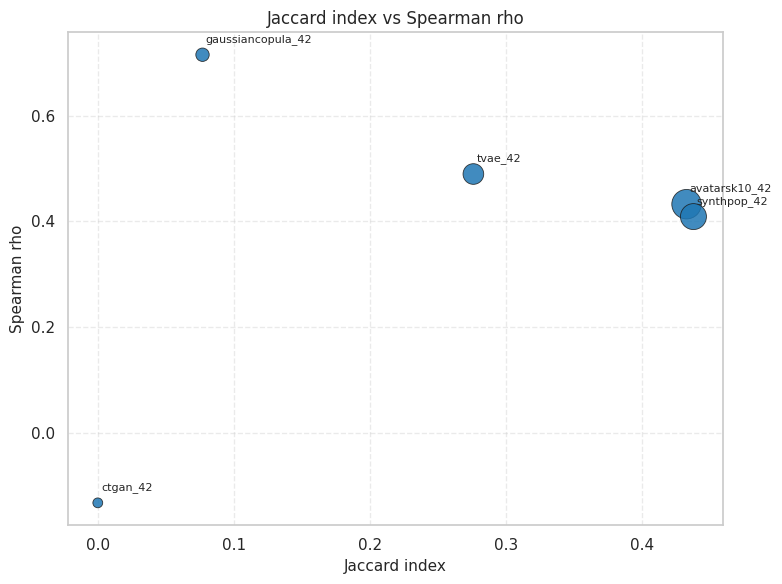

In [149]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=f"GSEA/JaccardIndex_Spearman_{seed}.png")
plt.show()

In [168]:
from typing import List, Optional, Any, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_pathway_df(
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    color_col: Optional[str] = None,
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    p_threshold: float = 0.05,
    cmap: Optional[Any] = None,
    fig_width_min: float = 10.0,
    marker_size: float = 100.0,   # fixed marker size (no scaling)
    show: bool = True,
    title: str = "Pathway bubble plot",
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    eps: float = 1e-9,  # small epsilon added to p-values before -log10
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:


    if df is None or df.empty:
        raise ValueError("Input DataFrame `df` is empty or None.")
    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")

    if cmap is None:
        cmap = plt.cm.plasma_r

    df = df.copy()

    # Coerce numeric columns safely
    if p_value_col in df.columns:
        df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    if color_col is not None and color_col in df.columns:
        # try to coerce numeric color columns; leave categorical as-is
        df[color_col] = pd.to_numeric(df[color_col], errors="coerce").fillna(df[color_col])

    # Compute -log10(p) helper (with eps) if p-values exist
    if p_value_col in df.columns:
        p_series = df[p_value_col].fillna(1.0).astype(float)
        p_series_clipped = p_series.clip(lower=eps)
        df["_log10_pvalue_helper"] = -np.log10(p_series_clipped)
    else:
        df["_log10_pvalue_helper"] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.", ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    # Determine ordering of y labels
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    # Final y labels (reverse for top-to-bottom plotting)
    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # Choose color column
    color_col_use = color_col if color_col is not None else "_log10_pvalue_helper"
    if color_col_use not in df_plot.columns:
        raise ValueError(f"color column '{color_col_use}' not found in filtered DataFrame.")

    # Extract plotting arrays
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values

    color_series = df_plot[color_col_use]
    if pd.api.types.is_numeric_dtype(color_series):
        color_plot = color_series.astype(float).values
    else:
        # map categorical colors to integer codes
        categories = pd.Categorical(color_series)
        color_plot = categories.codes.astype(float)

    # Use fixed marker size for all points
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # Normalize color
    if color_col_use == "_log10_pvalue_helper":
        norm_color_min = -np.log10(p_threshold + eps)
        color_max = np.nanmax(color_plot)
        if np.isnan(color_max) or color_max < (norm_color_min + 0.1):
            color_max = norm_color_min + 1.0
        norm = Normalize(vmin=norm_color_min, vmax=color_max)
        cbar_label = "$-\\log_{10}(p)$"
    else:
        finite_color = color_plot[np.isfinite(color_plot)]
        if finite_color.size == 0:
            norm = Normalize(vmin=0, vmax=1)
        else:
            norm = Normalize(vmin=np.nanmin(finite_color), vmax=np.nanmax(finite_color))
        cbar_label = color_col_use

    # Create figure
    FIG_WIDTH = max(fig_width_min, 10.0)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 2, 6)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=color_plot,
        cmap=cmap,
        norm=norm,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # vertical line at 0 if numeric x
    if np.any(np.isfinite(x_plot)):
        max_abs_x = np.nanmax(np.abs(x_plot[np.isfinite(x_plot)]))
        ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
        ax.set_xlim(-max_abs_x * 1.05, max_abs_x * 1.05)
    else:
        ax.set_xlim(-1, 1)

    # Ensure ticks and labels are visible
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Highlight pathways on y-axis labels
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="8%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # Make room for y-labels if they are long
    plt.subplots_adjust(left=0.30, right=0.88, top=0.95, bottom=0.08)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    # attach mapping y positions to df_plot for downstream usage
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    return (fig, df_plot) if return_dataframe else (fig, None)

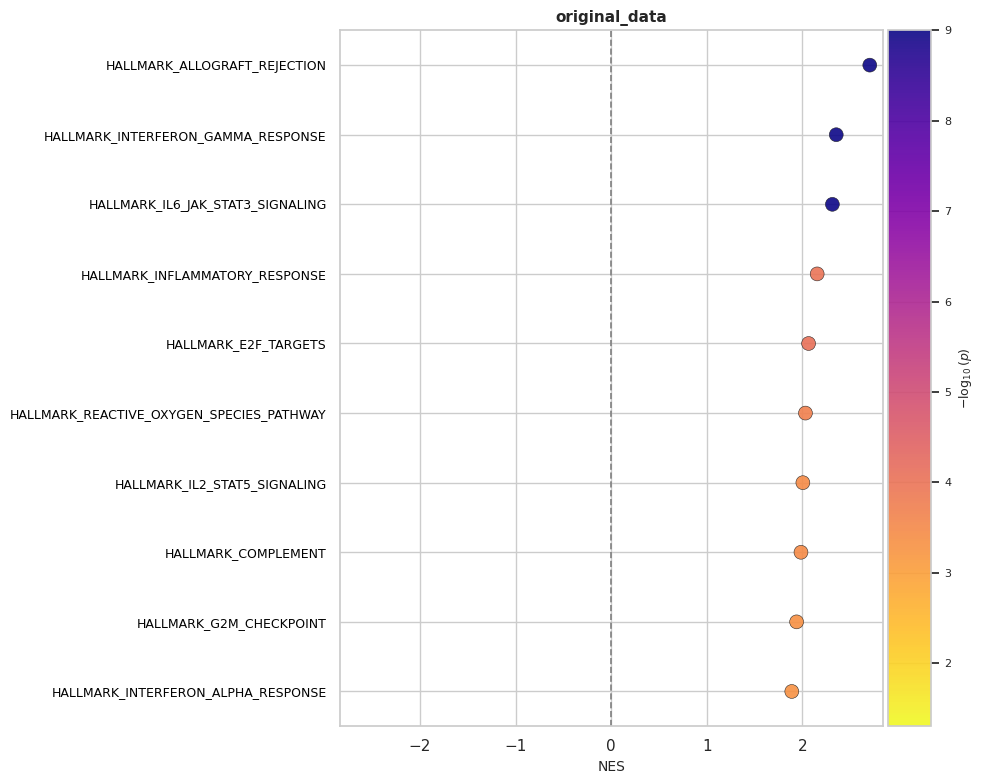

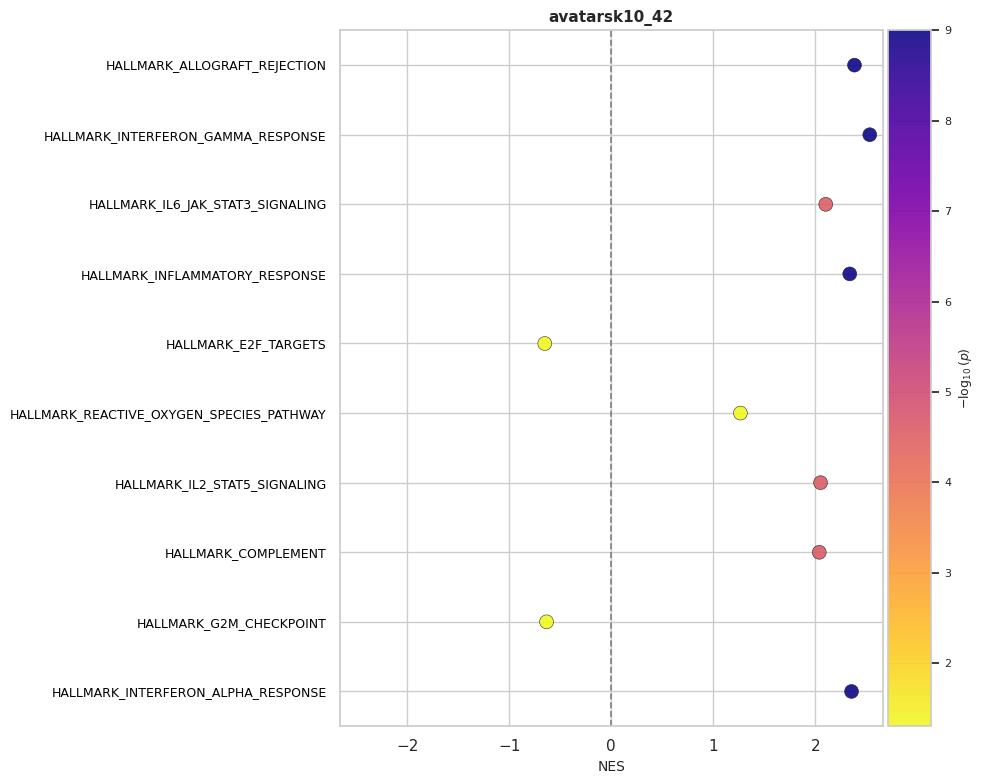

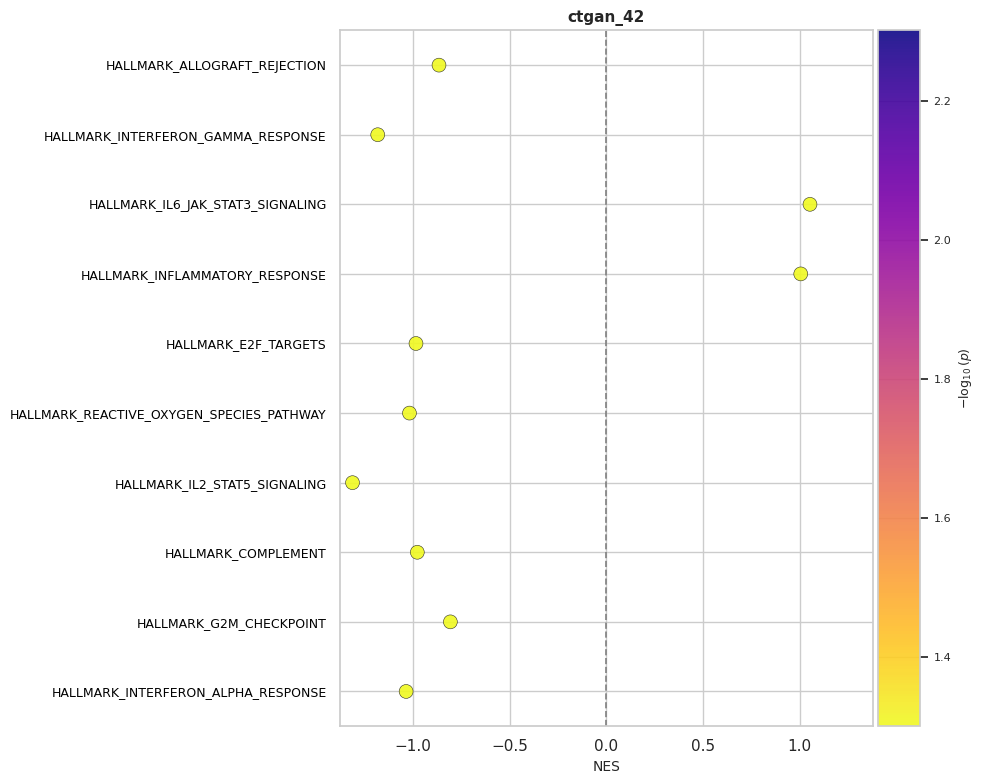

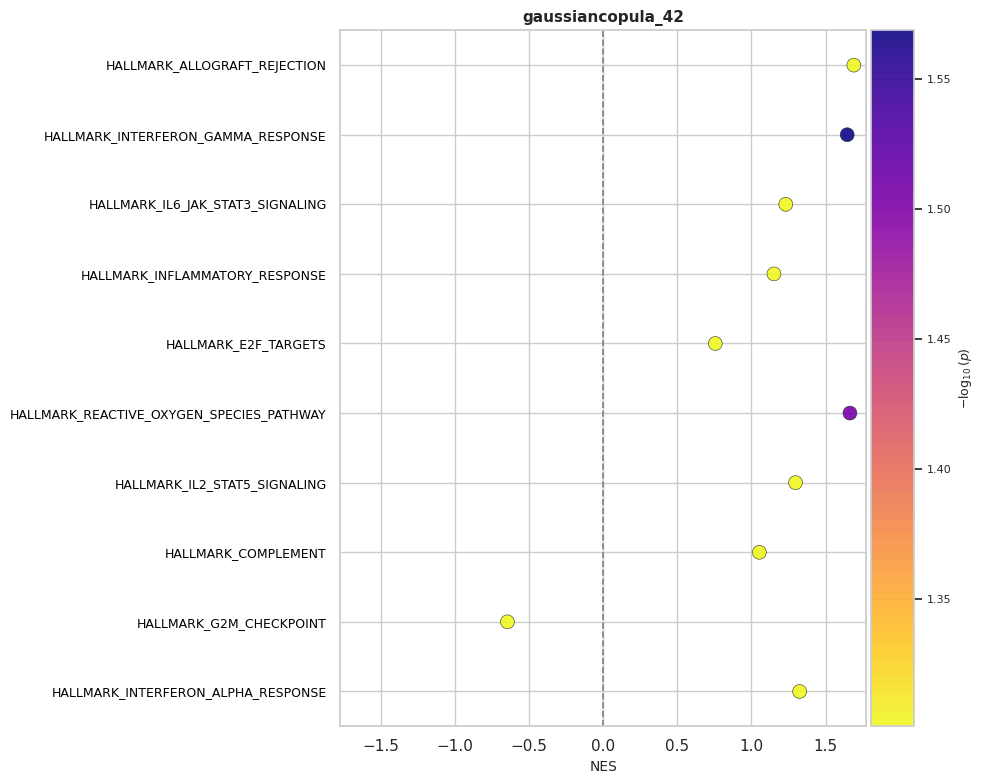

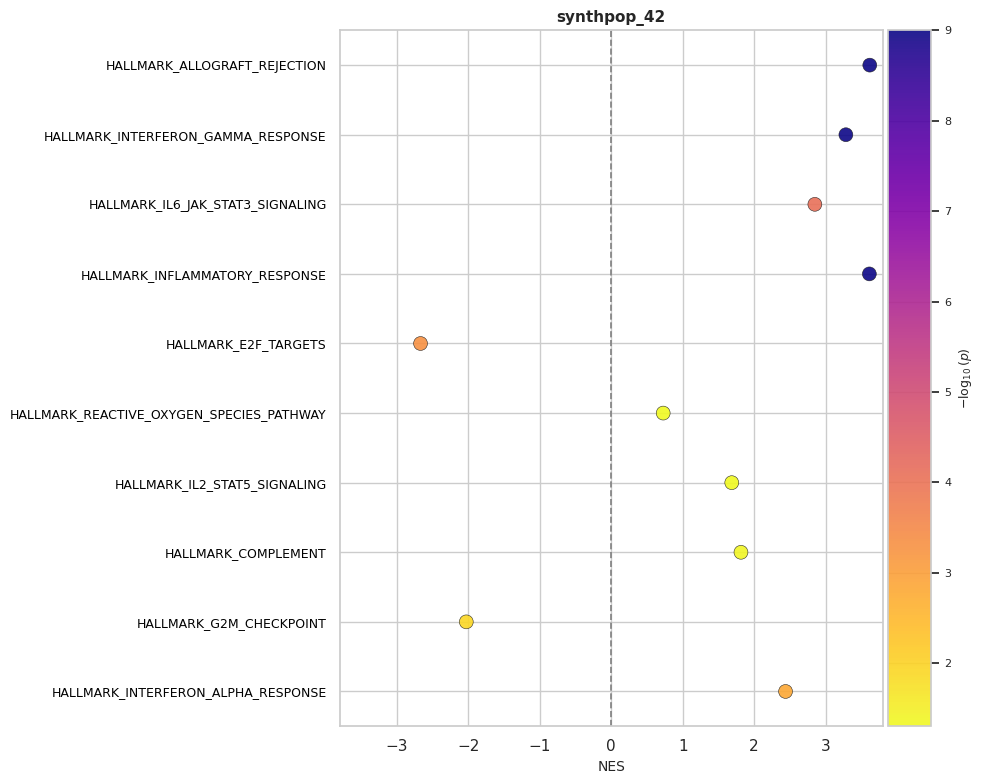

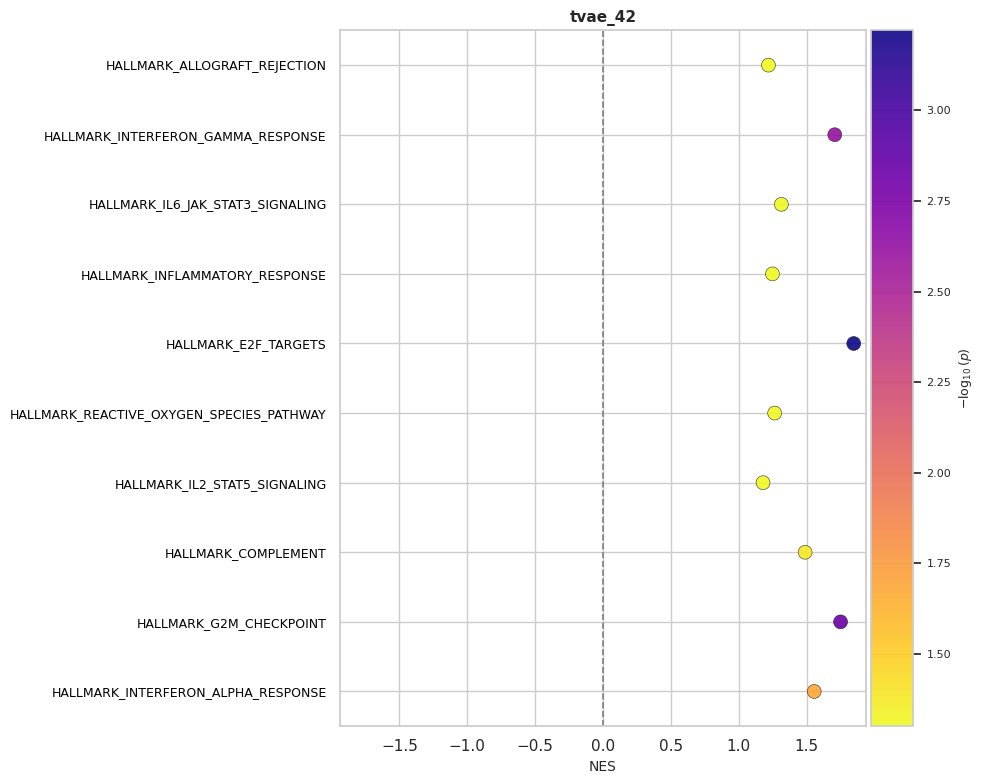

In [170]:
# Example usage:
for tool, GSEA_df in GSEA_overall.items():
    fig, df_out = plot_pathway_df(GSEA_df, ref_pathway_list=orig_paths[0:10], x_col="NES", y_col="Term",
                                  p_value_col="FDR q-val", highlight_pathways=None, title = f"{tool}",
                                    save_path =f"GSEA/BubblePlot_{tool}_{seed}.png",
                                   color_col=None, order_by=None)

## Ipi Treated Difference

In [174]:
print("---Ipi-Experience---")
degs_results_ipitreated = {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    data = data[data["daysBiopsyAfterIpiStart"]=="postIpi"]
    genelist = data.columns.tolist()[54:-1]
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PD_Responders": data["PD_Responders"].values.tolist()}
    )
    gene_expressions = data[genelist]
    id_col = "Patient"
    phenotypes = {"PD_Responders": ["Responder","Progressor"]}
    degs_df = degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    degs_results_ipitreated[name] = degs_df

---Ipi-Experience---
----DEGs Analysis original_data ----


DE analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:45<00:00, 415.18it/s]


----DEGs Analysis avatarsk10_42 ----


DE analysis: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:01<00:00, 11890.70it/s]


----DEGs Analysis ctgan_42 ----


...

DE analysis:   1%|█                                                                                                                                                                                                       | 100/18760 [00:00<00:20, 895.94it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   2%|████▉                                                                                                                                                                                                  | 460/18760 [00:00<00:08, 2181.41it/s]/tmp/ipykernel_2645569/3678970918.p

----DEGs Analysis synthpop_42 ----


DE analysis: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:01<00:00, 11851.90it/s]


----DEGs Analysis tvae_42 ----


DE analysis:   1%|██▎                                                                                                                                                                                                    | 220/18760 [00:00<00:16, 1096.01it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   3%|██████▌                                                                                                                                                                                                | 620/18760 [00:00<00:09, 2013.76it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.p

In [175]:
GSEA_IpiTreated = {}
for name, degs in degs_results_ipitreated.items():
    print(f"----GSEA {name}----")
    ranked_results_df = degs.sort_values(by="Rank_Score", ascending = False)
    rnk = ranked_results_df[["Gene","Rank_Score"]].set_index("Gene")
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=hallmarks_gmt,
                         threads=32,
                         permutation_num=10000, # reduce number to speed up testing
                         outdir=None, # don't write to disk
                         seed=seed,
                         verbose=True)
    prerank_ipitreated = pre_res.res2d
    # prerank_overall.to_csv(f"GSEA/GSEA_{name}_{seed}.csv",index = False)
    GSEA_IpiTreated[name] = prerank_ipitreated

2025-12-01 01:33:07,581 [WARNING] Duplicated values found in preranked stats: 99.80% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:33:07,583 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:33:07,613 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:33:07,614 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:33:07,615 [INFO] Start to run GSEA...Might take a while..................


----GSEA original_data----


2025-12-01 01:33:18,314 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:33:18,343 [WARNING] Duplicated values found in preranked stats: 99.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:33:18,344 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:33:18,373 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:33:18,374 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:33:18,375 [INFO] Start to run GSEA...Might take a while..................


----GSEA avatarsk10_42----


2025-12-01 01:33:28,743 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:33:28,762 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-12-01 01:33:28,779 [WARNING] Duplicated values found in preranked stats: 99.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:33:28,780 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:33:28,808 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:33:28,809 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:33:28,810 [INFO] Start to run GSEA...Might take a while..................


...

2025-12-01 01:33:48,922 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:33:48,939 [WARNING] Duplicated values found in preranked stats: 99.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:33:48,940 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:33:48,969 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:33:48,970 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:33:48,971 [INFO] Start to run GSEA...Might take a while..................


----GSEA synthpop_42----


2025-12-01 01:33:59,426 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:33:59,442 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-12-01 01:33:59,451 [WARNING] Duplicated values found in preranked stats: 99.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:33:59,452 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:33:59,480 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:33:59,482 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:33:59,482 [INFO] Start to run GSEA...Might take a while..................


----GSEA tvae_42----


2025-12-01 01:34:09,762 [INFO] Congratulations. GSEApy runs successfully................



In [176]:
print("---Ipi-Naive---")
degs_results_naive= {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    data = data[data["daysBiopsyAfterIpiStart"]=="noIpi"]
    genelist = data.columns.tolist()[54:-1]
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PD_Responders": data["PD_Responders"].values.tolist()}
    )
    gene_expressions = data[genelist]
    id_col = "Patient"
    phenotypes = {"PD_Responders": ["Responder","Progressor"]}
    degs_df = degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    degs_results_naive[name] = degs_df

---Ipi-Naive---
----DEGs Analysis original_data ----


DE analysis: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:01<00:00, 11818.53it/s]


----DEGs Analysis avatarsk10_42 ----


DE analysis: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:01<00:00, 12086.72it/s]


----DEGs Analysis ctgan_42 ----


...

DE analysis:   1%|█                                                                                                                                                                                                       | 100/18760 [00:00<00:21, 880.68it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   2%|████▉                                                                                                                                                                                                  | 460/18760 [00:00<00:08, 2199.11it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.p

----DEGs Analysis synthpop_42 ----


DE analysis: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18760/18760 [00:01<00:00, 12131.83it/s]


----DEGs Analysis tvae_42 ----


DE analysis:   1%|██▎                                                                                                                                                                                                     | 220/18760 [00:00<00:20, 913.67it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   3%|██████▌                                                                                                                                                                                                | 620/18760 [00:00<00:09, 1869.37it/s]/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
/tmp/ipykernel_2645569/3678970918.py:78: RuntimeWarning: invalid value encountered in log2
DE analysis:   7%|█████████████▎                                                                                              

In [177]:
GSEA_Naive = {}
for name, degs in degs_results_naive.items():
    print(f"----GSEA Naive {name}----")
    ranked_results_df = degs.sort_values(by="Rank_Score", ascending = False)
    rnk = ranked_results_df[["Gene","Rank_Score"]].set_index("Gene")
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=hallmarks_gmt,
                         threads=32,
                         permutation_num=10000, # reduce number to speed up testing
                         outdir=None, # don't write to disk
                         seed=seed,
                         verbose=True)
    prerank_naive = pre_res.res2d
    # prerank_overall.to_csv(f"GSEA/GSEA_{name}_{seed}.csv",index = False)
    GSEA_Naive[name] = prerank_naive

2025-12-01 01:35:24,878 [WARNING] Duplicated values found in preranked stats: 99.09% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:35:24,879 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:35:24,908 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:35:24,909 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:35:24,910 [INFO] Start to run GSEA...Might take a while..................


----GSEA Naive original_data----


2025-12-01 01:35:35,461 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:35:35,480 [WARNING] Duplicated values found in preranked stats: 98.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:35:35,481 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:35:35,510 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:35:35,511 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:35:35,512 [INFO] Start to run GSEA...Might take a while..................


----GSEA Naive avatarsk10_42----


2025-12-01 01:35:46,038 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:35:46,058 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-12-01 01:35:46,071 [WARNING] Duplicated values found in preranked stats: 98.32% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:35:46,073 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:35:46,100 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:35:46,102 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:35:46,103 [INFO] Start to run GSEA...Might take a while..................


...

2025-12-01 01:36:06,719 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:36:06,736 [WARNING] Duplicated values found in preranked stats: 99.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:36:06,738 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:36:06,766 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:36:06,767 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:36:06,768 [INFO] Start to run GSEA...Might take a while..................


----GSEA Naive synthpop_42----


2025-12-01 01:36:17,266 [INFO] Congratulations. GSEApy runs successfully................

2025-12-01 01:36:17,283 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-12-01 01:36:17,291 [WARNING] Duplicated values found in preranked stats: 98.97% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-01 01:36:17,292 [INFO] Parsing data files for GSEA.............................
2025-12-01 01:36:17,321 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-01 01:36:17,322 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-01 01:36:17,323 [INFO] Start to run GSEA...Might take a while..................


----GSEA Naive tvae_42----


2025-12-01 01:36:27,776 [INFO] Congratulations. GSEApy runs successfully................



In [180]:
prerank_overall = GSEA_overall["original_data"]
prerank_ipitreated = GSEA_IpiTreated["original_data"]
prerank_ipinaive = GSEA_Naive["original_data"]

pathways = ["HALLMARK_INTERFERON_GAMMA_RESPONSE","HALLMARK_INTERFERON_ALPHA_RESPONSE"]
subgroups = ["Overall","Ipi-Exp","Ipi-Naive"]
graphDFs = []
for pathway in pathways:
    overall_qvalue = prerank_overall[prerank_overall["Term"]==pathway]["FDR q-val"].values
    ipitreated_qvalue = prerank_ipitreated[prerank_ipitreated["Term"]==pathway]["FDR q-val"].values
    ipinaive_qvalue = prerank_ipinaive[prerank_ipinaive["Term"]==pathway]["FDR q-val"].values
    graphDF = pd.DataFrame(
        {"Subgroup": subgroups,
         "FDR q-value": [float(overall_qvalue), float(ipitreated_qvalue), float(ipinaive_qvalue)],
         "Pathway": [pathway]*len(subgroups)
        }
    ) 
    # generate the visualization
    qval = []
    for x in graphDF["FDR q-value"]:
        if x == 0:
            qval += [4] # 10^-4 is the limit for our q-values
        elif x == 1:
            qval += [0.1] # for visualization purposes
        else:
            q = -math.log(x,10)
            if q < 0.1:
                q = 0.1 # for visualization purposes
            qval += [q]
    graphDF["-Log10Qvalue"] = qval
    graphDFs.append(graphDF)
graphDF_final = pd.concat(graphDFs, axis = 0)

In [187]:
from matplotlib.patches import Rectangle

def plot_pathways_side_by_side(
    graphDF_final: pd.DataFrame,
    pathways: list,
    subgroups: list,
    figsize=(12, 6),
    savepath = None,
    custom_palette: dict = None,
):
    # default palette if none provided
    if custom_palette is None:
        custom_palette = {'Overall': '#E41A1C', 'Ipi-Exp': '#377EB8', 'Ipi-Naive': '#4DAF4A'}

    # defensive checks
    if not pathways:
        raise ValueError("`pathways` must be a non-empty list.")
    if not subgroups:
        raise ValueError("`subgroups` must be a non-empty list.")
    for sg in subgroups:
        if sg not in custom_palette:
            custom_palette[sg] = '#808080'  # fallback gray

    ncols = len(pathways)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, ncols, wspace=0.3)

    # Build legend handles in the desired order
    legend_labels = subgroups
    legend_handles = [Rectangle((0, 0), 1, 1, fc=custom_palette[subgroup]) for subgroup in legend_labels]

    for i, pathway in enumerate(pathways):
        ax = fig.add_subplot(gs[0, i])

        # Filter data for the current pathway
        plot_data = graphDF_final[graphDF_final["Pathway"] == pathway]

        # Ensure consistent ordering of x categories and hue
        sns.barplot(
            ax=ax,
            x='Subgroup',
            y='-Log10Qvalue',
            hue='Subgroup',
            data=plot_data,
            dodge=False,
            palette=custom_palette,
            order=subgroups,
            hue_order=subgroups,
        )

        # Title
        title = str(pathway).replace("_", " ").title()
        ax.set_title(title, fontsize=14, pad=10)

        # Y-axis ticks and labels (user provided mapping)
        yticks_val = [0, 1, 2, 3, 4]
        yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
        ax.set_yticks(yticks_val)
        ax.set_yticklabels(yticklabels_val)

        # Significance line at -Log10(0.1) = 1
        yline = 1.0
        xlim_max = len(subgroups) - 0.5
        ax.plot([-0.5, xlim_max], [yline, yline], color='red', linestyle='--', linewidth=1)

        # X and Y limits
        ax.set_xlim(-0.5, xlim_max)
        ax.set_ylim(0, 4.1)

        # Remove x-axis label text
        ax.set_xlabel("")

        # Y-axis label only on the first subplot
        if i == 0:
            ax.set_ylabel("FDR q-value", labelpad=10)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        # Remove the automatic legend added by seaborn for each axis if it exists
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    # Reserve space on the right for the legend and place it there
    fig.subplots_adjust(left=0.07, right=0.82, top=0.94, bottom=0.08)

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc='center left',
        bbox_to_anchor=(0.86, 0.5),
        title="Subgroup",
        frameon=False,
        fontsize=11,
        title_fontsize=12,
    )

    # Show figure
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    return fig

----original_data----


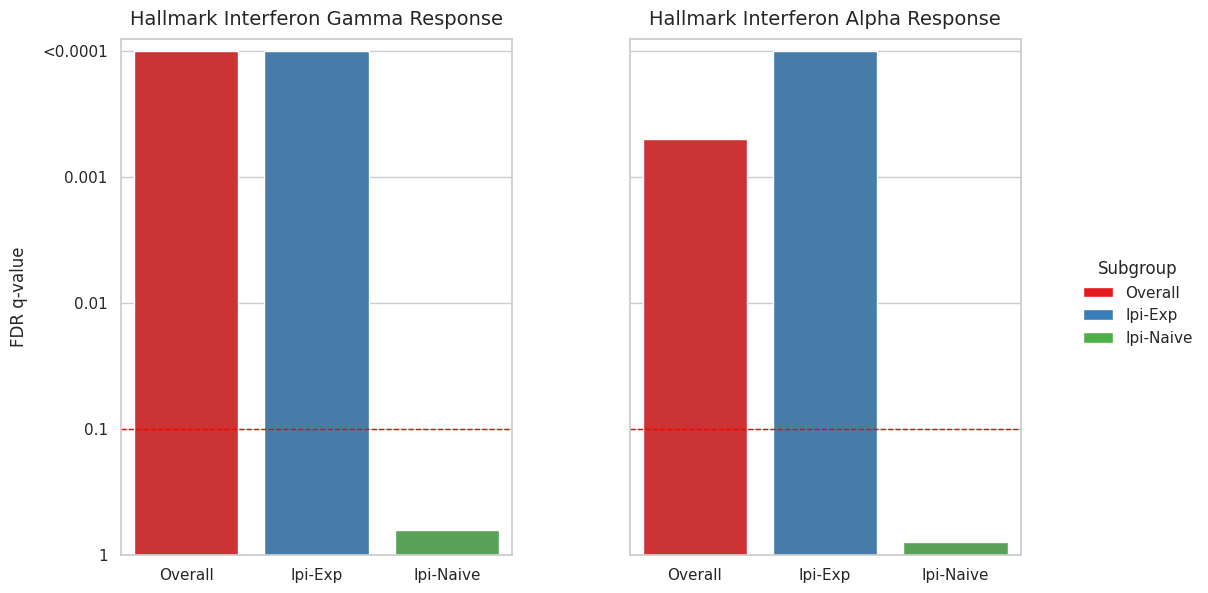

----avatarsk10_42----


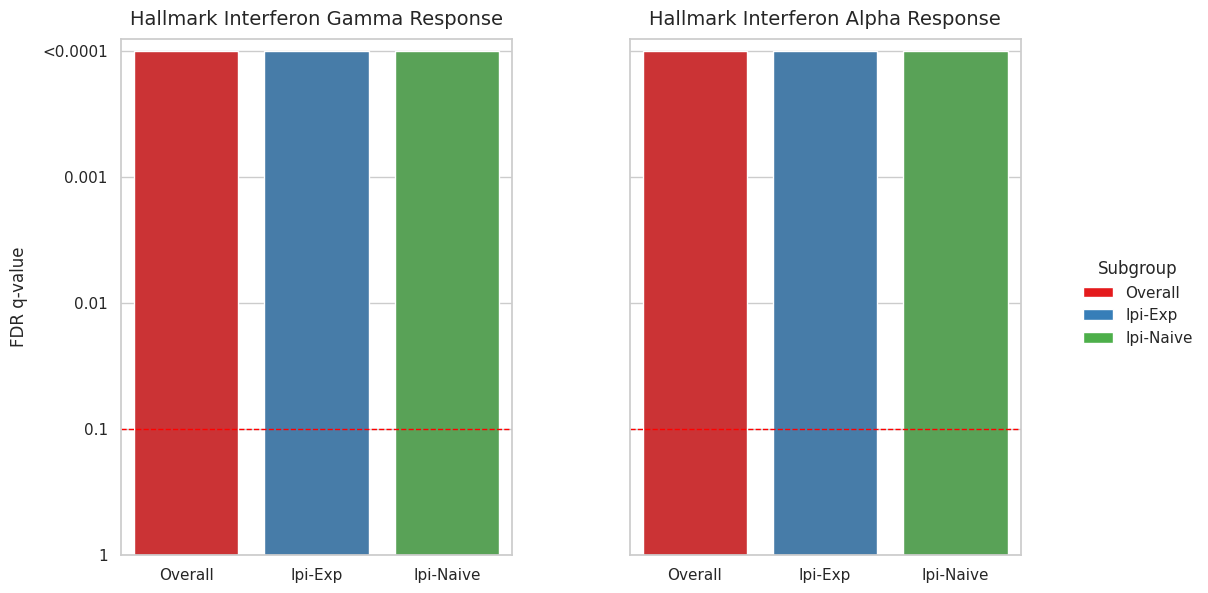

----ctgan_42----


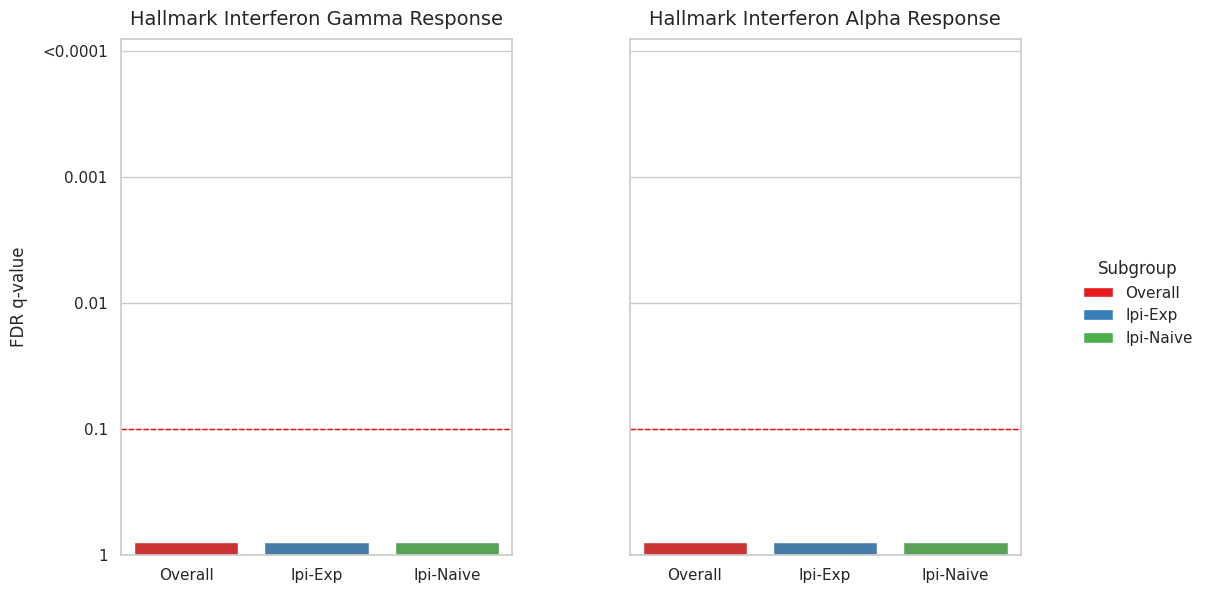

----gaussiancopula_42----


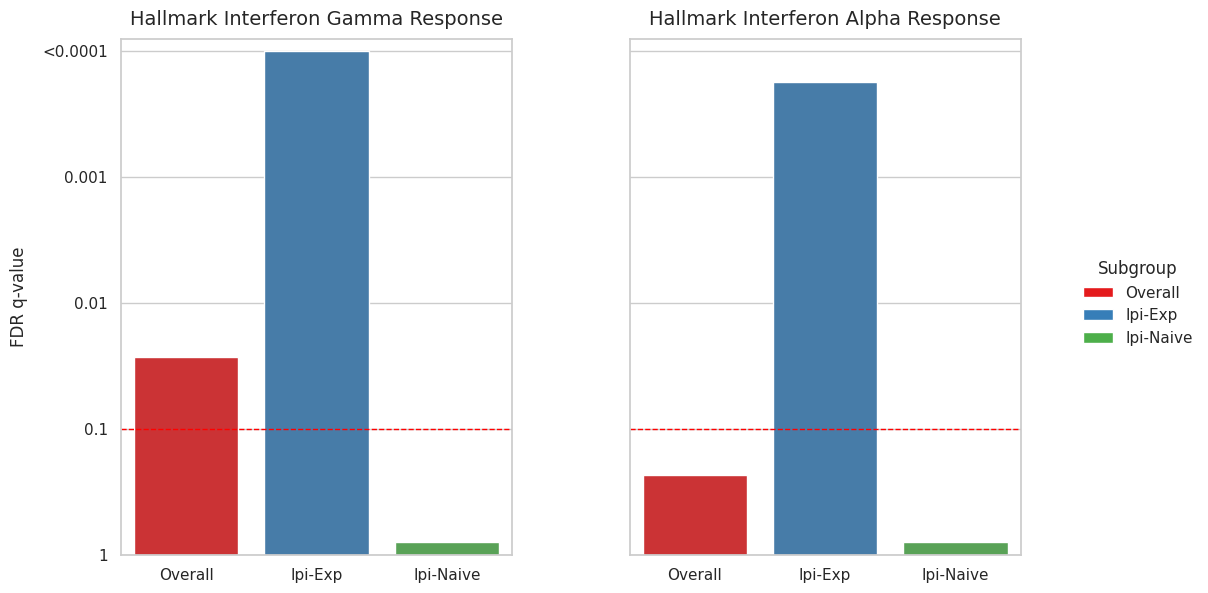

----synthpop_42----


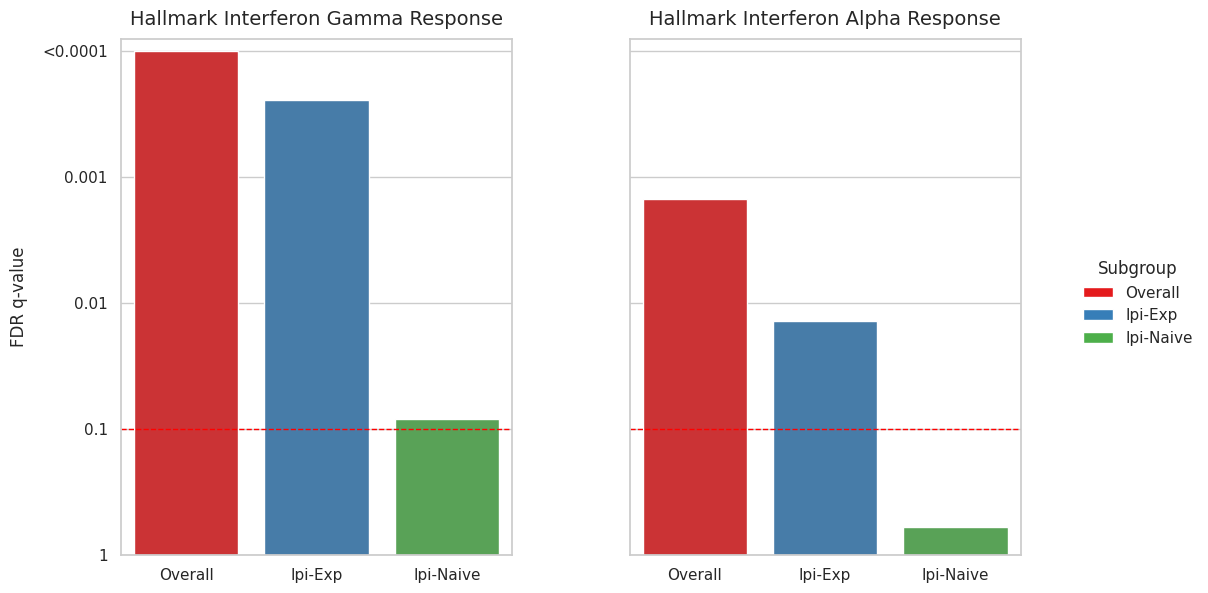

----tvae_42----


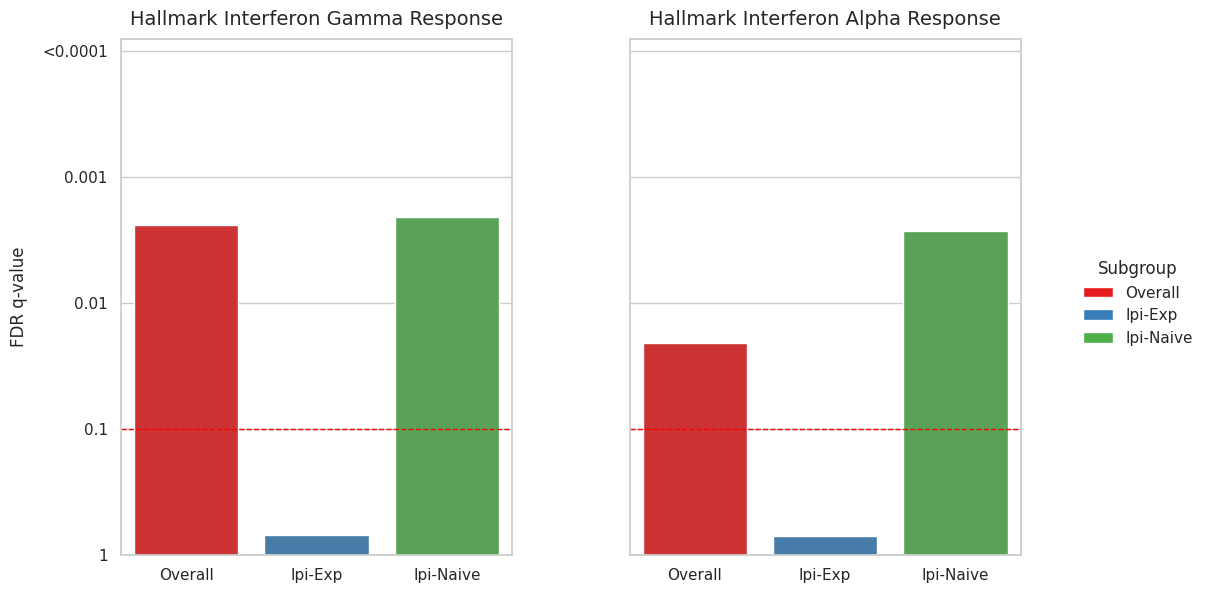

In [188]:
pathways = ["HALLMARK_INTERFERON_GAMMA_RESPONSE","HALLMARK_INTERFERON_ALPHA_RESPONSE"]
subgroups = ["Overall","Ipi-Exp","Ipi-Naive"]
for dataset in dataset_dict.keys():
    print(f"----{dataset}----")
    prerank_overall = GSEA_overall[dataset]
    prerank_ipitreated = GSEA_IpiTreated[dataset]
    prerank_ipinaive = GSEA_Naive[dataset]
    graphDFs = []
    for pathway in pathways:
        overall_qvalue = prerank_overall[prerank_overall["Term"]==pathway]["FDR q-val"].values
        ipitreated_qvalue = prerank_ipitreated[prerank_ipitreated["Term"]==pathway]["FDR q-val"].values
        ipinaive_qvalue = prerank_ipinaive[prerank_ipinaive["Term"]==pathway]["FDR q-val"].values
        graphDF = pd.DataFrame(
            {"Subgroup": subgroups,
             "FDR q-value": [float(overall_qvalue), float(ipitreated_qvalue), float(ipinaive_qvalue)],
             "Pathway": [pathway]*len(subgroups)
            }
        ) 
        # generate the visualization
        qval = []
        for x in graphDF["FDR q-value"]:
            if x == 0:
                qval += [4] # 10^-4 is the limit for our q-values
            elif x == 1:
                qval += [0.1] # for visualization purposes
            else:
                q = -math.log(x,10)
                if q < 0.1:
                    q = 0.1 # for visualization purposes
                qval += [q]
        graphDF["-Log10Qvalue"] = qval
        graphDFs.append(graphDF)
    graphDF_final = pd.concat(graphDFs, axis = 0)
    fig = plot_pathways_side_by_side(graphDF_final,pathways,subgroups, savepath = f"GSEA/PathwayDiff_IpiSubgroups_{dataset}_{seed}.png")